🔎 What is Orchestrator–Worker in LangGraph?

Orchestrator = the manager node that decides what needs to be done, breaks a problem into subtasks, and assigns them to the right worker.

Workers = specialized nodes/agents that perform the actual subtasks (e.g., researcher, writer, summarizer).

The orchestrator doesn’t solve the problem itself — it delegates.
Workers don’t make global decisions — they just execute tasks given by the orchestrator.

⚖️ Analogy

👉 Imagine a film production team:

Director (Orchestrator): Reads the script, decides what scenes to shoot, assigns them to different departments.

Workers (Cameraman, Actor, Sound Engineer, Editor): Each performs their specific role when asked.

The final movie is the result of orchestration + execution.

Without the director, the workers would be busy but uncoordinated.
Without the workers, the director would have ideas but no execution.

This is exactly how Orchestrator–Worker works in LangGraph.

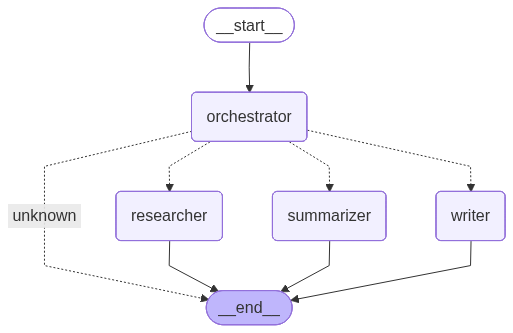

In [1]:
from langgraph.graph import StateGraph, END
from typing_extensions import TypedDict
from IPython.display import Image, display

# -------------------------------
# Define the State
# -------------------------------
class State(TypedDict):
    query: str
    task: str
    result: str

# -------------------------------
# Worker Nodes
# -------------------------------
def researcher_node(state: State):
    return {"result": f"📚 Research findings about {state['query']}"}

def writer_node(state: State):
    return {"result": f"✍️ Written article draft on {state['query']}"}

def summarizer_node(state: State):
    return {"result": f"📝 Concise summary of {state['query']}"}

# -------------------------------
# Orchestrator Node
# -------------------------------
def orchestrator_node(state: State):
    query = state["query"].lower()
    if "research" in query:
        return {"task": "researcher"}
    elif "write" in query:
        return {"task": "writer"}
    elif "summary" in query or "summarize" in query:
        return {"task": "summarizer"}
    else:
        return {"task": "unknown"}

# -------------------------------
# Build the Graph
# -------------------------------
graph = StateGraph(State)

graph.add_node("orchestrator", orchestrator_node)
graph.add_node("researcher", researcher_node)
graph.add_node("writer", writer_node)
graph.add_node("summarizer", summarizer_node)

graph.set_entry_point("orchestrator")

graph.add_conditional_edges(
    "orchestrator",
    lambda state: state["task"],  # routing decision
    {
        "researcher": "researcher",
        "writer": "writer",
        "summarizer": "summarizer",
        "unknown": END
    }
)

# All workers go to END
graph.add_edge("researcher", END)
graph.add_edge("writer", END)
graph.add_edge("summarizer", END)

# Compile
app = graph.compile()

# View
display(Image(app.get_graph().draw_mermaid_png()))




In [2]:
# -------------------------------
# Run Examples
# -------------------------------
print(app.invoke({"query": "Do research on climate change"}))
# → {'query': 'Do research on climate change', 'task': 'researcher', 'result': '📚 Research findings about Do research on climate change'}

print(app.invoke({"query": "Write an article on AI"}))
# → {'query': 'Write an article on AI', 'task': 'writer', 'result': '✍️ Written article draft on Write an article on AI'}

print(app.invoke({"query": "Summarize the history of blockchain"}))
# → {'query': 'Summarize the history of blockchain', 'task': 'summarizer', 'result': '📝 Concise summary of Summarize the history of blockchain'}

{'query': 'Do research on climate change', 'task': 'researcher', 'result': '📚 Research findings about Do research on climate change'}
{'query': 'Write an article on AI', 'task': 'writer', 'result': '✍️ Written article draft on Write an article on AI'}
{'query': 'Summarize the history of blockchain', 'task': 'summarizer', 'result': '📝 Concise summary of Summarize the history of blockchain'}


🔑 Key Takeaways

Orchestrator Node = “Manager”
Decides which worker should handle the current state/query.

Workers Nodes = “Specialists”
Perform the actual task (research, writing, summarizing, etc.).

Conditional edges = The routing table that links the orchestrator’s decision to the right worker.

👉 In short:
Orchestrator–Worker in LangGraph is like a project manager assigning tasks to a specialized team.
The orchestrator keeps the big picture, and workers execute their expertise.

🚀 Extended Orchestrator–Worker with Parallel Workers

Sometimes the orchestrator may decide:

"This query needs both research and writing."

"This query needs research + summary."

Instead of sequential execution, we can run parallel workers in LangGraph.

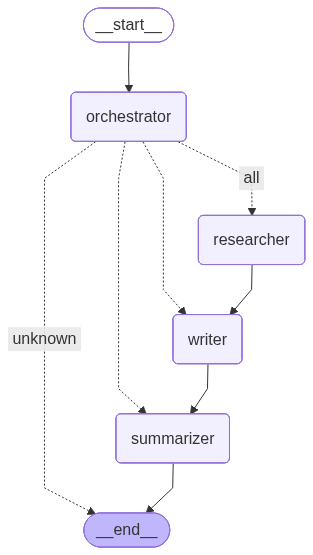

In [4]:
from langgraph.graph import StateGraph, END
from typing_extensions import TypedDict
from IPython.display import Image, display

# -------------------------------
# Define the State
# -------------------------------
class State(TypedDict):
    query: str
    task: str
    research: str
    draft: str
    summary: str

# -------------------------------
# Worker Nodes
# -------------------------------
def researcher_node(state: State):
    return {"research": f"📚 Research findings about {state['query']}"}

def writer_node(state: State):
    research_input = state.get("research", "no research available")
    return {"draft": f"✍️ Draft article on {state['query']} using {research_input}"}

def summarizer_node(state: State):
    draft_input = state.get("draft", "no draft available")
    return {"summary": f"📝 Concise summary of article: {draft_input}"}

# -------------------------------
# Orchestrator Node
# -------------------------------
def orchestrator_node(state: State):
    query = state["query"].lower()

    if "full report" in query:
        # Needs all three: research → writing → summary
        return {"task": "all"}
    elif "research" in query:
        return {"task": "researcher"}
    elif "write" in query:
        return {"task": "writer"}
    elif "summary" in query or "summarize" in query:
        return {"task": "summarizer"}
    else:
        return {"task": "unknown"}

# -------------------------------
# Build the Graph
# -------------------------------
graph = StateGraph(State)

graph.add_node("orchestrator", orchestrator_node)
graph.add_node("researcher", researcher_node)
graph.add_node("writer", writer_node)
graph.add_node("summarizer", summarizer_node)

graph.set_entry_point("orchestrator")

# Routing logic
graph.add_conditional_edges(
    "orchestrator",
    lambda state: state["task"],
    {
        "researcher": "researcher",
        "writer": "writer",
        "summarizer": "summarizer",
        "all": "researcher",   # Start with researcher when full report is needed
        "unknown": END
    }
)

# Sequential path for "all" workflow
graph.add_edge("researcher", "writer")
graph.add_edge("writer", "summarizer")
graph.add_edge("summarizer", END)

# If single tasks
graph.add_edge("researcher", END)
graph.add_edge("writer", END)
graph.add_edge("summarizer", END)

# Compile
app = graph.compile()

# View
display(Image(app.get_graph().draw_mermaid_png()))

In [5]:
# -------------------------------
# Run Examples
# -------------------------------
print("\n--- Single Worker Example ---")
print(app.invoke({"query": "Do research on AI ethics"}))

print("\n--- Parallel Workers Example (Full Report) ---")
print(app.invoke({"query": "Generate a full report on climate change"}))


--- Single Worker Example ---
{'query': 'Do research on AI ethics', 'task': 'researcher', 'research': '📚 Research findings about Do research on AI ethics', 'draft': '✍️ Draft article on Do research on AI ethics using 📚 Research findings about Do research on AI ethics', 'summary': '📝 Concise summary of article: ✍️ Draft article on Do research on AI ethics using 📚 Research findings about Do research on AI ethics'}

--- Parallel Workers Example (Full Report) ---
{'query': 'Generate a full report on climate change', 'task': 'all', 'research': '📚 Research findings about Generate a full report on climate change', 'draft': '✍️ Draft article on Generate a full report on climate change using 📚 Research findings about Generate a full report on climate change', 'summary': '📝 Concise summary of article: ✍️ Draft article on Generate a full report on climate change using 📚 Research findings about Generate a full report on climate change'}


⚖️ Analogy (Parallel Workers)

Think of building a car:

Orchestrator (Factory Manager): Decides this car needs engine + body + paint.

Workers:

Engineer → builds the engine.

Designer → builds the body.

Painter → paints it.

Sometimes only an engine check is required (single worker).
Sometimes a full car assembly is required (all workers in sequence).

The orchestrator manages the flow, workers specialize in execution.

👉 This shows how LangGraph Orchestrator–Worker can be used for both single task delegation and multi-step workflows (sequential/parallel).